# Fundamentos de Álgebra Linear com PyTorch

Este notebook serve como uma introdução aos conceitos fundamentais da Álgebra Linear, a matemática dos dados. A compreensão profunda destes conceitos é um pré-requisito para o estudo avançado de qualquer campo da Inteligência Artificial.

## 1. Escalares, Vetores, Matrizes e Tensores

A Álgebra Linear lida fundamentalmente com vetores. No entanto, é útil começar com as estruturas que os englobam.

-   **Escalar**: Um único número, como $x \in \mathbb{R}$.
-   **Vetor**: Um array de números ordenados. Um vetor $v \in \mathbb{R}^n$ possui $n$ componentes, $v = [v_1, v_2, ..., v_n]$. Geralmente, nos referimos a ele como um vetor coluna:
$$ v = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix} $$
-   **Matriz**: Um array bidimensional de números. Uma matriz $A \in \mathbb{R}^{m \times n}$ tem $m$ linhas e $n$ colunas.
$$ A = \begin{bmatrix}
A_{1,1} & A_{1,2} & \cdots & A_{1,n} \\
A_{2,1} & A_{2,2} & \cdots & A_{2,n} \\
\vdots & \vdots & \ddots & \vdots \\
A_{m,1} & A_{m,2} & \cdots & A_{m,n}
\end{bmatrix} $$
-   **Tensor**: É uma generalização de um escalar (tensor de ordem 0), um vetor (tensor de ordem 1) e uma matriz (tensor de ordem 2) para um número arbitrário de dimensões (ordem $d$).

In [590]:
import torch

# Verificando a versão do PyTorch
print(f"Versão do PyTorch: {torch.__version__}")

Versão do PyTorch: 2.10.0


In [591]:
# Escalar (Tensor de ordem 0)
escalar = torch.tensor(3.14)
print("Escalar:")
print(escalar)
print("Ordem (ndim):", escalar.ndim)
print("Shape:", escalar.shape)

Escalar:
tensor(3.1400)
Ordem (ndim): 0
Shape: torch.Size([])


In [592]:
# Vetor (Tensor de ordem 1)
vetor = torch.tensor([1, 2, 3])
print("Vetor:")
print(vetor)
print("Ordem (ndim):", vetor.ndim)
print("Shape:", vetor.shape)

Vetor:
tensor([1, 2, 3])
Ordem (ndim): 1
Shape: torch.Size([3])


In [593]:
# Matriz (Tensor de ordem 2)
matriz = torch.tensor([[1, 2], [3, 4], [5, 6]])
print("Matriz:")
print(matriz)
print("Ordem (ndim):", matriz.ndim)
print("Shape:", matriz.shape) # 3 linhas, 2 colunas

Matriz:
tensor([[1, 2],
        [3, 4],
        [5, 6]])
Ordem (ndim): 2
Shape: torch.Size([3, 2])


## 2. Criação e Manipulação de Tensores em PyTorch

Embora possamos criar tensores a partir de listas Python, PyTorch oferece funções otimizadas para criar tensores comumente utilizados e para manipular seu formato.

### Funções de Criação
- `torch.ones(shape)`: Cria um tensor preenchido com o valor 1.
- `torch.zeros(shape)`: Cria um tensor preenchido com o valor 0.
- `torch.rand(shape)`: Cria um tensor com valores aleatórios de uma distribuição uniforme em $[0, 1)$.
- `torch.randn(shape)`: Cria um tensor com valores aleatórios de uma distribuição normal padrão (média 0, variância 1).
- `torch.arange(start, end, step)`: Cria um tensor com valores em um intervalo.
- `torch.linspace(start, end, steps)`: Cria um tensor com um número específico de valores (`steps`) espaçados linearmente entre `start` e `end`.

### Manipulação de Formato
- `.shape`: Atributo que retorna a dimensionalidade do tensor.
- `.reshape(new_shape)` / `.view(new_shape)`: Remodelam o tensor para um novo formato. `view` é mais rápido, mas só funciona em tensores contíguos na memória. `reshape` é mais flexível.
- `.flatten()`: Transforma um tensor multidimensional em um tensor 1D (um vetor).

In [594]:
x = torch.zeros(2, 3)
print("Tensor de Zeros (2, 3):\n", x)

Tensor de Zeros (2, 3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [595]:
x = torch.ones(3, 2)
print("Tensor de Uns (3, 2):\n", x)

Tensor de Uns (3, 2):
 tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])


In [596]:
x = torch.arange(0, 5)
print("Tensor com arange(0, 5):\n", x)

Tensor com arange(0, 5):
 tensor([0, 1, 2, 3, 4])


In [597]:
x = torch.linspace(0, 1, 5)
print("Tensor com linspace(0, 1, 5 passos):\n", x)

Tensor com linspace(0, 1, 5 passos):
 tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [598]:
x = torch.rand(2, 2)
print("Tensor Rand (dist. uniforme):\n", x)

Tensor Rand (dist. uniforme):
 tensor([[0.0788, 0.5016],
        [0.4174, 0.1860]])


In [599]:
x = torch.randn(2, 2)
print("Tensor Randn (dist. normal):\n", x)

Tensor Randn (dist. normal):
 tensor([[-1.2405,  0.0569],
        [ 0.6233,  0.8194]])


In [600]:
# Manipulação de formato
x = torch.arange(12)
print("--- Manipulação de Formato ---")
print("\nTensor original (x):\n", x)
print("Shape de x:", x.shape)

--- Manipulação de Formato ---

Tensor original (x):
 tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Shape de x: torch.Size([12])


In [601]:
# Reshape
x_reshaped = x.reshape(3, 4)
print("x com reshape(3, 4):\n", x_reshaped)
print("Shape de x_reshaped:", x_reshaped.shape)

x com reshape(3, 4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Shape de x_reshaped: torch.Size([3, 4])


In [602]:
# Flatten
x_flattened = x_reshaped.flatten()
print("x_reshaped achatado (flatten):\n", x_flattened)
print("Shape de x_flattened:", x_flattened.shape)

x_reshaped achatado (flatten):
 tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Shape de x_flattened: torch.Size([12])


## 3. Indexação e Fatiamento

Acessar e modificar subconjuntos de um tensor é uma operação rotineira. A sintaxe em PyTorch é similar à do NumPy, utilizando colchetes `[]` e o operador de fatiamento `:` (dois pontos). A indexação começa em zero.

-   Acessar um elemento: `T[i, j]` para o elemento na linha `i` e coluna `j`.
-   Acessar uma linha: `T[i, :]` para a linha `i` inteira.
-   Acessar uma coluna: `T[:, j]` para a coluna `j` inteira.
-   Acessar um subconjunto: `T[start_row:end_row, start_col:end_col]`.

In [603]:
# Criando um tensor 2D para os exemplos
T = torch.arange(20).reshape(5, 4)

print("Tensor original (5x4):\n", T)

Tensor original (5x4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])


In [604]:
# Acessando a linha de índice 1
T_linha_1 = T[1, :]
print("Linha de índice 1 (T[1, :]):\n", T_linha_1)

Linha de índice 1 (T[1, :]):
 tensor([4, 5, 6, 7])


In [605]:
# Acessando a coluna de índice 2
T_coluna_2 = T[:, 2]
print("Coluna de índice 2 (T[:, 2]):\n", T_coluna_2)

Coluna de índice 2 (T[:, 2]):
 tensor([ 2,  6, 10, 14, 18])


In [606]:
# Acessando o elemento na linha 3, coluna 1
T_el = T[3, 1]
print("Elemento em (3, 1):", T_el.item())

Elemento em (3, 1): 13


In [607]:
# Fatiando para obter um sub-bloco (linhas 1 e 2, colunas 0 e 1)
sub_bloco = T[1:3, 0:2]
print("Sub-bloco T[1:3, 0:2]:\n", sub_bloco)

Sub-bloco T[1:3, 0:2]:
 tensor([[4, 5],
        [8, 9]])


## 4. Redução de Tensores

Operações de redução agregam todos os valores de um tensor (ou de uma de suas dimensões) em um único valor, como soma, média, produto, etc.

- `torch.sum()`: Soma dos elementos.
- `torch.mean()`: Média dos elementos.
- `torch.prod()`: Produto dos elementos.
- `torch.max()` / `torch.min()`: Valores máximo e mínimo.

O argumento `dim` especifica a dimensão ao longo da qual a operação é aplicada.
- `dim=0`: Reduz ao longo das linhas (resultando em um valor por coluna).
- `dim=1`: Reduz ao longo das colunas (resultando em um valor por linha).

In [608]:
T = torch.arange(1, 7, dtype=torch.float32).reshape(2, 3)
print("Tensor original:\n", T)

# Redução total
print("\nSoma total (sum):", T.sum().item())
print("Média total (mean):", T.mean().item())

# Redução por dimensão
soma_colunas = T.sum(dim=0)
print("\nSoma ao longo das linhas (dim=0):", soma_colunas)

soma_linhas = T.sum(dim=1)
print("Soma ao longo das colunas (dim=1):", soma_linhas)

max_vals, max_indices = T.max(dim=1)
print("\nValores máximos por linha (dim=1):", max_vals)

Tensor original:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])

Soma total (sum): 21.0
Média total (mean): 3.5

Soma ao longo das linhas (dim=0): tensor([5., 7., 9.])
Soma ao longo das colunas (dim=1): tensor([ 6., 15.])

Valores máximos por linha (dim=1): tensor([3., 6.])


## 5. Operações com Vetores

As operações mais básicas em Álgebra Linear são a adição de vetores e a multiplicação por escalar.

### Adição de Vetores
A soma de dois vetores $u, v \in \mathbb{R}^n$ é realizada elemento a elemento:
$$ w = u + v \quad \text{onde} \quad w_i = u_i + v_i $$

### Multiplicação por Escalar
A multiplicação de um vetor $v \in \mathbb{R}^n$ por um escalar $c \in \mathbb{R}$ resulta em um novo vetor onde cada elemento é multiplicado por $c$:
$$ w = c v \quad \text{onde} \quad w_i = c \cdot v_i $$
Geometricamente, isso "escala" (estica ou encolhe) o vetor $v$.

In [609]:
# Adição de Vetores
u = torch.tensor([1, 2, 3])
v = torch.tensor([10, 20, 30])
soma_vetores = u + v
print("Adição de Vetores (u + v):")
print(soma_vetores)

Adição de Vetores (u + v):
tensor([11, 22, 33])


In [610]:
# Multiplicação por Escalar
c = 2
w = c * u
print(f"Multiplicação por Escalar ({c} * u):")
print(w)

Multiplicação por Escalar (2 * u):
tensor([2, 4, 6])


### Exercícios: Criação e Manipulação de Tensores

1.  **Tensor Aleatório**: Crie um tensor de formato `(5, 5)` com números aleatórios provenientes de uma distribuição normal padrão.
2.  **Sequência Linear**: Crie um vetor (tensor 1D) que comece em -10, termine em 10 e contenha exatamente 50 pontos.
3.  **Remodelagem**: Crie um vetor com 100 elementos usando `torch.arange`. Em seguida, remodele-o para que tenha o formato `(10, 10)`.
4.  **Achatamento para Redes Neurais**: Crie um tensor que simule um lote (batch) de 4 imagens em escala de cinza de tamanho 28x28 (formato `(4, 28, 28)`). Em seguida, "achate" cada imagem para que o tensor final tenha o formato `(4, 784)`, que é um formato comum para a entrada de uma camada densa (fully-connected).

#### Exercício 1:

In [611]:
t5x5 = torch.randn(5, 5)
print(f"t5x5.shape: {t5x5.shape}")
print(f"t5x5: {t5x5}")

t5x5.shape: torch.Size([5, 5])
t5x5: tensor([[ 0.3844, -0.2012,  0.0063,  1.9454,  0.7753],
        [ 0.3724, -0.1984, -0.6481, -2.4069,  0.6012],
        [-0.5946,  0.0782, -1.1338, -1.3756, -0.2784],
        [-1.7841, -0.6501,  0.3945,  0.7503, -1.2447],
        [ 0.9242,  0.3873,  0.3395, -1.0019,  1.3374]])


#### Exercício 2:

In [612]:
t1x10 = torch.linspace(-10, 10, 50)
print(f"t1x10.shape: {t1x10.shape}")
print(f"t1x10.len: {len(t1x10)}")
print(f"t1x10: {t1x10}")

t1x10.shape: torch.Size([50])
t1x10.len: 50
t1x10: tensor([-10.0000,  -9.5918,  -9.1837,  -8.7755,  -8.3673,  -7.9592,  -7.5510,
         -7.1429,  -6.7347,  -6.3265,  -5.9184,  -5.5102,  -5.1020,  -4.6939,
         -4.2857,  -3.8776,  -3.4694,  -3.0612,  -2.6531,  -2.2449,  -1.8367,
         -1.4286,  -1.0204,  -0.6122,  -0.2041,   0.2041,   0.6122,   1.0204,
          1.4286,   1.8367,   2.2449,   2.6531,   3.0612,   3.4694,   3.8776,
          4.2857,   4.6939,   5.1020,   5.5102,   5.9184,   6.3265,   6.7347,
          7.1429,   7.5510,   7.9592,   8.3673,   8.7755,   9.1837,   9.5918,
         10.0000])


#### Exercício 3:

In [613]:
t100 = torch.arange(100)
print(f"t100.shape: {t100.shape}")
print(f"t100: {t100}")

t10x10 = t100.reshape(10, 10)
print(f"t10x10.shape: {t10x10.shape}")
print(f"t10x10: {t10x10}")

t100.shape: torch.Size([100])
t100: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
        54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
        72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
        90, 91, 92, 93, 94, 95, 96, 97, 98, 99])
t10x10.shape: torch.Size([10, 10])
t10x10: tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24, 25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
        [40, 41, 42, 43, 44, 45, 46, 47, 48, 49],
        [50, 51, 52, 53, 54, 55, 56, 57, 58, 59],
        [60, 61, 62, 63, 64, 65, 66, 67, 68, 69],
        [70, 71, 72, 73, 74, 75, 76, 77, 78, 79],
        [80, 81, 82, 83, 84, 85, 86, 87, 88, 89],
        [90, 91, 92, 9

#### Exercício 4:

In [614]:
print(f"\nExercício 4:")
batch = torch.randn(4, 28, 28) 
print(f"batch.shape: {batch.shape}")
print(f"batch: {batch}")

batch_flat = batch.flatten(start_dim=1)
print(f"batch_flat.shape: {batch_flat.shape}")
print(f"batch_flat: {batch_flat}")



Exercício 4:
batch.shape: torch.Size([4, 28, 28])
batch: tensor([[[-3.2625e-01,  8.8531e-02, -1.1232e-01,  ..., -1.4791e-02,
          -2.6598e+00,  1.7084e+00],
         [ 1.0888e-02,  4.3419e-01,  1.0513e+00,  ...,  1.7286e+00,
           5.3772e-02,  1.3021e+00],
         [-2.3341e-01,  4.9393e-01,  2.3969e-01,  ...,  6.1732e-03,
           1.8570e+00,  1.4926e+00],
         ...,
         [ 8.2470e-01,  1.6782e+00, -5.4727e-02,  ..., -9.6730e-01,
           4.9530e-01, -1.2279e+00],
         [-7.4929e-02, -1.0555e+00,  3.4933e-01,  ..., -1.2565e+00,
           2.8832e-01,  1.0271e+00],
         [ 1.1838e+00,  2.8431e-01,  1.3102e+00,  ..., -9.6184e-01,
           1.1199e+00,  1.8986e+00]],

        [[ 5.2009e-01, -1.6552e-01,  1.6847e+00,  ..., -6.2783e-01,
           4.2551e-01,  2.0357e+00],
         [-9.0278e-01,  1.8464e-01,  6.4184e-01,  ..., -8.6289e-01,
           7.4341e-01,  2.1223e+00],
         [ 2.5689e+00,  3.5460e-01,  5.6069e-01,  ..., -1.2951e-02,
          -1.4968e

### Exercícios: Indexação e Fatiamento

Use o tensor abaixo para resolver os exercícios:
`T = torch.arange(25).reshape(5, 5)`

1.  **Seleção Simples**: Selecione e imprima o número `13` do tensor `T`.
2.  **Linha Inteira**: Selecione e imprima a terceira linha inteira (a que contém os elementos 10, 11, 12, 13, 14).
3.  **Sub-bloco Central**: Selecione e imprima o sub-bloco 3x3 que fica no centro da matriz `T`. O resultado deve ser:
    ```
    tensor([[ 6,  7,  8],
            [11, 12, 13],
            [16, 17, 18]])
    ```
4.  **Padrão Xadrez (Desafio)**: Selecione todos os elementos nas "casas pares" da matriz (e.g., T[0,0], T[0,2], T[0,4], T[2,0], etc.).
5.  **Modificação por Fatiamento**: Usando fatiamento, substitua o sub-bloco central 3x3 (o mesmo do exercício 3) por uma matriz de zeros do mesmo tamanho. Imprima o tensor `T` modificado.

#### Exercício 1:

In [615]:
T = torch.arange(25).reshape(5, 5)
print(f"T.shape: {T.shape}")
print(f"T: {T}")

print()
print(f"Seleção simples: T[2,3]: {T[2, 3]}")


T.shape: torch.Size([5, 5])
T: tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19],
        [20, 21, 22, 23, 24]])

Seleção simples: T[2,3]: 13


#### Exercício 2:

In [616]:

print(f"Linha Inteira: T[:,2]: {T[2, :]}")


Linha Inteira: T[:,2]: tensor([10, 11, 12, 13, 14])


#### Exercício 3:

In [617]:

print(f"Sub-bloco Central: T[3:3,3:3]: {T[1:4, 1:4]}")



Sub-bloco Central: T[3:3,3:3]: tensor([[ 6,  7,  8],
        [11, 12, 13],
        [16, 17, 18]])


#### Exercício 4:

In [618]:
i = torch.arange(5)
j = torch.arange(5)
mask = (i.unsqueeze(1) + j.unsqueeze(0)) % 2 == 0
T[mask]

print(f"Padrão Xadrez: T[mask]: {T[mask]}")


Padrão Xadrez: T[mask]: tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24])


#### Exercício 5:

In [619]:

T_mod = T.clone()
T_mod[1:4, 1:4] = torch.zeros(3, 3)
print()
print(f"Modificação por Fatiamento: T[1:4, 1:4] = torch.zeros(3, 3): {T_mod}")


Modificação por Fatiamento: T[1:4, 1:4] = torch.zeros(3, 3): tensor([[ 0,  1,  2,  3,  4],
        [ 5,  0,  0,  0,  9],
        [10,  0,  0,  0, 14],
        [15,  0,  0,  0, 19],
        [20, 21, 22, 23, 24]])


### Exercícios: Redução de Tensores

Crie um tensor aleatório de formato `(4, 6)` para os exercícios a seguir.
`dados = torch.rand(4, 6)`

1.  **Média Geral**: Calcule a média de todos os elementos no tensor `dados`.
2.  **Soma por Coluna**: Calcule a soma de cada coluna. O resultado deve ser um vetor com 6 elementos.
3.  **Valor Mínimo por Linha**: Encontre o valor mínimo de cada linha. O resultado deve ser um vetor com 4 elementos.
4.  **Desvio Padrão**: Calcule o desvio padrão de cada coluna do tensor. (Dica: use `torch.std`).

In [620]:
dados = torch.rand(4, 6)
print(f"dados.shape: {dados.shape}")
print(f"dados: {dados}")

dados.shape: torch.Size([4, 6])
dados: tensor([[0.8728, 0.2150, 0.6509, 0.6456, 0.8900, 0.9578],
        [0.5255, 0.3556, 0.1783, 0.7839, 0.2951, 0.2937],
        [0.7804, 0.4248, 0.2334, 0.9913, 0.3007, 0.2298],
        [0.7962, 0.0163, 0.1285, 0.3755, 0.6245, 0.8338]])


#### Exercício 1:

In [621]:
print(f"Média Geral: dados.mean(): {dados.mean()}")

Média Geral: dados.mean(): 0.5166385769844055


#### Exercício 2:

In [622]:
print(f"Soma por Coluna: dados.sum(dim=0): {dados.sum(dim=0)}")

Soma por Coluna: dados.sum(dim=0): tensor([2.9750, 1.0118, 1.1911, 2.7962, 2.1104, 2.3150])


#### Exercício 3:

In [623]:

print(f"Valor Mínimo por Linha: dados.min(dim=1): {dados.min(dim=1)}")

Valor Mínimo por Linha: dados.min(dim=1): torch.return_types.min(
values=tensor([0.2150, 0.1783, 0.2298, 0.0163]),
indices=tensor([1, 2, 5, 1]))


#### Exercício 4:

In [624]:

print(f"Desvio Padrão: dados.std(dim=0): {dados.std(dim=0)}")

Desvio Padrão: dados.std(dim=0): tensor([0.1510, 0.1803, 0.2393, 0.2583, 0.2865, 0.3705])


### Exercícios: Operações com Vetores

Considere os vetores  
$u = \begin{bmatrix}1 \\ 2\end{bmatrix}, \quad v = \begin{bmatrix}3 \\ -1\end{bmatrix}$  

1. **Adição e Subtração**: Calcule $u + v$ e $u - v$

2. **Multiplicação por Escalar**: Calcule $3u$

3. **Combinação Linear**: Calcule o vetor $w = 2u + 0.5v$ 

4. **Interpretação Geométrica (Teórico)**: Sem calcular, apenas descreva geometricamente, qual seria a relação entre o vetor $u$ e o vetor $z = -u$

In [625]:
u = torch.tensor([1, 2])
print(f"u: {u}")
v = torch.tensor([3, -1])
print(f"v: {v}")

u: tensor([1, 2])
v: tensor([ 3, -1])


#### Exercício 1:

In [626]:

print(f"u + v: {u + v}")
print(f"u - v: {u - v}")


u + v: tensor([4, 1])
u - v: tensor([-2,  3])


#### Exercício 2:

In [627]:
print(f"3u: {3 * u}")


3u: tensor([3, 6])


#### Exercício 3:

In [628]:

w = 2 * u + 0.5 * v
print()
print(f"w = 2u + 0.5v: {w}")



w = 2u + 0.5v: tensor([3.5000, 3.5000])


#### Exercício 4:

z = -u: representa geometricamente um vetor de mesmo tamanho que u mas com direção oposta

## 6. Norma de um Vetor

A norma de um vetor é uma medida do seu "comprimento" ou "magnitude". A norma mais comum é a norma Euclidiana, ou norma $\ell_2$. Para um vetor $v \in \mathbb{R}^n$, a norma $\ell_2$, denotada por $||v||_2$, é calculada como:

$$ ||v||_2 = \sqrt{\sum_{i=1}^{n} v_i^2} = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2} $$

A norma de um vetor é sempre um valor não-negativo.

In [629]:
v = torch.tensor([3.0, 4.0])

# Calculando a norma l2
# sqrt(3^2 + 4^2) = sqrt(9 + 16) = sqrt(25) = 5
norma_v = torch.linalg.norm(v)

print("Vetor v:", v)
print("Norma l2 de v:", norma_v.item())

Vetor v: tensor([3., 4.])
Norma l2 de v: 5.0


In [630]:
# Vetor unitário: um vetor com norma igual a 1
# Para obter um vetor unitário, dividimos o vetor pela sua norma
v_unitario = v / norma_v
print("Vetor unitário de v:", v_unitario)
print("Norma do vetor unitário:", torch.linalg.norm(v_unitario).item())

Vetor unitário de v: tensor([0.6000, 0.8000])
Norma do vetor unitário: 1.0


## 7. Produto Interno e Ângulo entre Vetores

O produto interno (ou produto escalar, *dot product*) de dois vetores $u, v \in \mathbb{R}^n$ é a soma dos produtos dos elementos correspondentes:

$$ u^T v = u \cdot v = \sum_{i=1}^{n} u_i v_i $$

Ele possui uma propriedade geométrica fundamental que o relaciona ao ângulo $\theta$ entre os vetores:

$$ u \cdot v = ||u||_2 \ ||v||_2 \ \cos(\theta) $$

Podemos usar esta relação para encontrar o ângulo entre os vetores. Rearranjando a equação, temos:

$$ \cos(\theta) = \frac{u \cdot v}{||u||_2 \ ||v||_2} $$

E, finalmente, o ângulo $\theta$ é obtido pela função arco cosseno:

$$ \theta = \arccos\left(\frac{u \cdot v}{||u||_2 \ ||v||_2}\right) $$

Um produto interno de zero indica que os vetores são ortogonais ($\theta=90^\circ$).

In [631]:
u = torch.tensor([1, 2, 3])
v = torch.tensor([4, 5, 6])

# Calculando o produto interno
# 1*4 + 2*5 + 3*6 = 4 + 10 + 18 = 32
produto_interno = torch.dot(u, v)

print("Vetor u:", u)
print("Vetor v:", v)
print("Produto Interno (u . v):", produto_interno.item())

Vetor u: tensor([1, 2, 3])
Vetor v: tensor([4, 5, 6])
Produto Interno (u . v): 32


In [632]:
u = torch.tensor([1., 2.])
v = torch.tensor([3., 1.])

# 1. Calcular o produto interno
produto_interno = torch.dot(u, v)

# 2. Calcular a norma de cada vetor
norma_u = torch.linalg.norm(u)
norma_v = torch.linalg.norm(v)

# 3. Calcular o cosseno do ângulo
cos_theta = produto_interno / (norma_u * norma_v)

# 4. Calcular o ângulo em radianos usando arccos
theta_rad = torch.acos(cos_theta)

# Converter para graus
theta_deg = theta_rad * 180.0 / torch.pi

print(f"Cosseno do ângulo: {cos_theta.item():.2f}")
print(f"Ângulo em radianos: {theta_rad.item():.2f}")
print(f"Ângulo em graus: {theta_deg:.2f}°")

Cosseno do ângulo: 0.71
Ângulo em radianos: 0.79
Ângulo em graus: 45.00°


In [633]:
# Exemplo de vetores ortogonais
u_ort = torch.tensor([1., 0.])
v_ort = torch.tensor([0., 1.])
print("Produto Interno de vetores ortogonais:", torch.dot(u_ort, v_ort).item())

Produto Interno de vetores ortogonais: 0.0


## 8. Multiplicação de Matriz por Vetor

A multiplicação de uma matriz $A \in \mathbb{R}^{m \times n}$ por um vetor $v \in \mathbb{R}^n$ resulta em um novo vetor $b \in \mathbb{R}^m$. Essa operação representa uma **transformação linear**.

Pense na matriz $A$ como uma função que "transforma" o vetor $v$, que vive no espaço $\mathbb{R}^n$ (o espaço de entrada), e o mapeia para um novo vetor $b=Av$, que vive no espaço $\mathbb{R}^m$ (o espaço de saída). Essa transformação pode rotacionar, escalar ou cisalhar (shear) o vetor original.

O mecanismo desta transformação é que o vetor resultante $b$ é uma **combinação linear das colunas da matriz $A$**, onde os pesos dessa combinação são exatamente os **elementos do vetor $v$**:

$$ b = A v = v_1 \begin{bmatrix} A_{1,1} \\ \vdots \\ A_{m,1} \end{bmatrix} + v_2 \begin{bmatrix} A_{1,2} \\ \vdots \\ A_{m,2} \end{bmatrix} + \cdots + v_n \begin{bmatrix} A_{1,n} \\ \vdots \\ A_{m,n} \end{bmatrix} $$

In [634]:
# Matriz de transformação A (leva de R^2 para R^3)
A = torch.tensor([[1, 0],
                  [0, 1],
                  [1, 1]], dtype=torch.float32)

# Vetor original no espaço R^2
v = torch.tensor([2., 3.])

# Aplicar a transformação: A @ v
# O resultado será um novo vetor no espaço R^3
b = A @ v

print("Matriz de Transformação A (leva de R^2 para R^3):\n", A)
print("\nVetor original v (em R^2):\n", v)
print("\nVetor transformado b = A@v (em R^3):\n", b)

Matriz de Transformação A (leva de R^2 para R^3):
 tensor([[1., 0.],
        [0., 1.],
        [1., 1.]])

Vetor original v (em R^2):
 tensor([2., 3.])

Vetor transformado b = A@v (em R^3):
 tensor([2., 3., 5.])


In [635]:
# Verificando a intuição da combinação linear:
# b = 2 * A[:,0] + 3 * A[:,1]
b_combinacao_linear = v[0] * A[:, 0] + v[1] * A[:, 1]
print("Resultado via combinação linear das colunas:\n", b_combinacao_linear)

Resultado via combinação linear das colunas:
 tensor([2., 3., 5.])


## 9. Multiplicação de Matrizes: Composição de Transformações

Seguindo a mesma lógica, a multiplicação de duas matrizes, $C = AB$, representa a **composição de duas transformações lineares**.

Se uma matriz $B \in \mathbb{R}^{n \times p}$ transforma um vetor do espaço $\mathbb{R}^p$ para $\mathbb{R}^n$, e uma matriz $A \in \mathbb{R}^{m \times n}$ transforma um vetor de $\mathbb{R}^n$ para $\mathbb{R}^m$, então a matriz produto $C \in \mathbb{R}^{m \times p}$ representa a transformação única que leva diretamente do espaço $\mathbb{R}^p$ para $\mathbb{R}^m$.

Em outras palavras, aplicar a transformação $C$ a um vetor $v$ é o mesmo que aplicar primeiro a transformação $B$ e depois aplicar a transformação $A$ ao resultado:

$$ C v = (A B) v = A (B v) $$

Cada elemento $C_{ij}$ da matriz resultante é o produto interno da $i$-ésima linha da matriz $A$ com a $j$-ésima coluna da matriz $B$.

$$ C_{ij} = \sum_{k=1}^{n} A_{ik} B_{kj} $$

In [636]:
A = torch.tensor([[1, 2], [3, 4]]) # Matriz 2x2
B = torch.tensor([[10, 20], [30, 40]]) # Matriz 2x2

# Usando torch.matmul ou o operador @
C = torch.matmul(A, B)
# C = A @ B

print("Matriz A:\n", A)
print("\nMatriz B:\n", B)
print("\nResultado da multiplicação A @ B:\n", C)

# Verificando a não-comutatividade
print("\nResultado da multiplicação B @ A:\n", B @ A)

Matriz A:
 tensor([[1, 2],
        [3, 4]])

Matriz B:
 tensor([[10, 20],
        [30, 40]])

Resultado da multiplicação A @ B:
 tensor([[ 70, 100],
        [150, 220]])

Resultado da multiplicação B @ A:
 tensor([[ 70, 100],
        [150, 220]])


## 10. Distância entre Vetores

A distância entre dois pontos (representados por vetores) no espaço Euclidiano é o comprimento do vetor que conecta esses dois pontos. A distância Euclidiana entre dois vetores $u, v \in \mathbb{R}^n$ é definida como a norma do vetor diferença $u-v$:

$$ \text{dist}(u, v) = ||u - v||_2 = \sqrt{\sum_{i=1}^{n} (u_i - v_i)^2} $$

Este conceito é a base para muitos algoritmos de Machine Learning, como o k-Nearest Neighbors (k-NN).

In [637]:
u = torch.tensor([1., 5.])
v = torch.tensor([4., 1.])

# Calculando o vetor diferença
diferenca = u - v

# Calculando a norma do vetor diferença
distancia = torch.linalg.norm(diferenca)
# sqrt((1-4)^2 + (5-1)^2) = sqrt((-3)^2 + 4^2) = sqrt(9 + 16) = sqrt(25) = 5

print("Vetor u:", u)
print("Vetor v:", v)
print("Distância Euclidiana entre u e v:", distancia.item())

Vetor u: tensor([1., 5.])
Vetor v: tensor([4., 1.])
Distância Euclidiana entre u e v: 5.0


In [638]:
# PyTorch também tem uma função de conveniência para isso
distancia_pdist = torch.cdist(u.unsqueeze(0), v.unsqueeze(0))
print("Distância calculada com torch.cdist:", distancia_pdist.item())

Distância calculada com torch.cdist: 5.0


## 11. Broadcasting: Operações Inteligentes entre Tensores

Em muitas situações, desejamos realizar operações entre tensores que não possuem exatamente o mesmo formato. O caso mais simples é operar um escalar com um tensor (e.g., somar o número 5 a todos os elementos de uma matriz). Uma abordagem mais complexa seria somar um vetor a cada linha de uma matriz.

Broadcasting é um mecanismo poderoso e eficiente que realiza essas operações sem a necessidade de criar cópias dos dados na memória. Ele define um conjunto de regras para tratar tensores de formatos diferentes. A operação é possível se, ao comparar os formatos dos tensores da direita para a esquerda (a partir da última dimensão), uma das duas condições for verdadeira para cada par de dimensões:

1.  As dimensões são iguais.
2.  Uma das dimensões é 1 (um escalar é tratado como se tivesse dimensões de tamanho 1).

Se essas condições forem satisfeitas, o tensor com a dimensão menor é virtualmente "esticado" (broadcasted) para corresponder ao tamanho da dimensão do outro tensor.

**Exemplo:** Somar um vetor de formato `(3,)` a uma matriz de formato `(2, 3)`.

1.  Alinhamos os formatos pela direita:
    - Matriz: `2, 3`
    - Vetor: `   3`
2.  Comparando a última dimensão: `3` e `3`. Elas são iguais. (OK)
3.  Comparando a penúltima dimensão: `2` e (não existe). O PyTorch adiciona uma dimensão de tamanho 1 ao vetor:
    - Matriz: `2, 3`
    - Vetor:  `1, 3`
4.  Agora, comparamos a primeira dimensão: `2` e `1`. Como uma delas é `1`, a condição é satisfeita. (OK)

O vetor de formato `(1, 3)` é então "esticado" para o formato `(2, 3)` e a soma é realizada.

In [639]:
# Exemplo 0: Somando um escalar a um tensor (caso mais simples)
matriz_base = torch.arange(6).reshape(2, 3)
escalar = 100

# Formatos:
# Matriz:   (2, 3)
# Escalar:  () -> é "esticado" para o formato (2, 3)
resultado_escalar = matriz_base + escalar

print("--- Broadcasting de Escalar ---")
print("Matriz (2, 3):\n", matriz_base)
print("\nEscalar:", escalar)
print("\nResultado (Matriz + Escalar):\n", resultado_escalar)

--- Broadcasting de Escalar ---
Matriz (2, 3):
 tensor([[0, 1, 2],
        [3, 4, 5]])

Escalar: 100

Resultado (Matriz + Escalar):
 tensor([[100, 101, 102],
        [103, 104, 105]])


In [640]:
# Exemplo 1: Somando um vetor-linha a uma matriz
matriz = torch.ones((3, 4)) # Matriz 3x4
vetor_linha = torch.arange(4, dtype=torch.float32) # Vetor 1x4

# Formatos:
# Matriz:      (3, 4)
# Vetor-linha:    (4,) -> alinhado como (1, 4)
# O vetor é "esticado" para o formato (3, 4) e somado a cada linha
resultado = matriz + vetor_linha

print("--- Broadcasting de Vetor-Linha ---")
print("Matriz (3, 4):\n", matriz)
print("\nVetor-linha (4,):\n", vetor_linha)
print("\nResultado (Matriz + Vetor-linha):\n", resultado)

--- Broadcasting de Vetor-Linha ---
Matriz (3, 4):
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Vetor-linha (4,):
 tensor([0., 1., 2., 3.])

Resultado (Matriz + Vetor-linha):
 tensor([[1., 2., 3., 4.],
        [1., 2., 3., 4.],
        [1., 2., 3., 4.]])


In [641]:
# Exemplo 2: Somando um vetor-coluna a uma matriz
vetor_coluna = torch.arange(3, dtype=torch.float32).reshape(3, 1) # Vetor 3x1

# Formatos:
# Matriz:       (3, 4)
# Vetor-coluna: (3, 1)
# O vetor-coluna é "esticado" nas colunas para o formato (3, 4)
resultado_col = matriz + vetor_coluna

print("--- Broadcasting de Vetor-Coluna ---")
print("Matriz (3, 4):\n", matriz)
print("\nVetor-coluna (3, 1):\n", vetor_coluna)
print("\nResultado (Matriz + Vetor-coluna):\n", resultado_col)

--- Broadcasting de Vetor-Coluna ---
Matriz (3, 4):
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Vetor-coluna (3, 1):
 tensor([[0.],
        [1.],
        [2.]])

Resultado (Matriz + Vetor-coluna):
 tensor([[1., 1., 1., 1.],
        [2., 2., 2., 2.],
        [3., 3., 3., 3.]])


### Exercícios: Norma de um Vetor

1. **Cálculo de Norma $\ell_2$**: Calcule a norma Euclidiana ($\ell_2$) do vetor $v = \begin{bmatrix}5 \\ 12\end{bmatrix}$. O resultado deve ser um número inteiro.  

2. **Cálculo de Norma $\ell_1$**: A norma $\ell_1$ (ou norma de Manhattan) é a soma dos valores absolutos dos componentes do vetor:  
   $||v||_1 = \sum_{i=1}^{n} |v_i|$  
   Calcule a norma $\ell_1$ do mesmo vetor $v$ do exercício 1.  

3. **Vetor Unitário (Versor)**: Crie um vetor unitário (um vetor com norma $\ell_2$ igual a 1) a partir do vetor $w = \begin{bmatrix}1 \\ 2 \\ 3\end{bmatrix}$. Para isso, divida o vetor $w$ pela sua norma.  

4. **Verificação**: Verifique que o vetor que você criou no exercício 3 realmente tem norma igual a 1. (Pode haver um erro mínimo de ponto flutuante, e.g., 0.999999).  

In [642]:
v = torch.tensor([5., 12.])

#### Exercício 1:

In [643]:
print(f"Norma Euclidiana de v: {torch.linalg.norm(v).item()}")

Norma Euclidiana de v: 13.0


#### Exercício 2:

In [644]:
print(f"Norma de Manhattan de v: {torch.linalg.norm(v, ord=1).item()}")

Norma de Manhattan de v: 17.0


#### Exercício 3:

In [645]:

w = torch.tensor([1., 2., 3.])
w_unitario = w / torch.linalg.norm(w).item()

print()
print(f"Vetor unitário de w: {w_unitario}")



Vetor unitário de w: tensor([0.2673, 0.5345, 0.8018])


#### Exercício 4:

In [646]:

print(f"Norma de w_unitário: {torch.linalg.norm(w_unitario).item():.4f}")

Norma de w_unitário: 1.0000


### Exercícios: Produto Interno e Ângulo

1. **Ortogonalidade**: Considere os vetores $u = \begin{bmatrix}2 \\ -1 \\ 1\end{bmatrix}$ e $v = \begin{bmatrix}1 \\ 2 \\ 0\end{bmatrix}$. Calcule o produto interno entre eles. Eles são ortogonais? Justifique.  

2. **Projeção**: O produto interno pode ser usado para calcular a projeção de um vetor sobre o outro. A projeção escalar de $u$ sobre $v$ é dada por  
   $\dfrac{u \cdot v}{||v||_2}$  
   Calcule essa projeção para os vetores do exercício anterior.  

3. **Ângulo Geométrico**: Crie dois vetores 2D quaisquer e calcule o ângulo (em graus) entre eles. Lembre que o ângulo pode ser obtido por  
   $\theta = \cos^{-1}\left(\dfrac{u \cdot v}{||u||_2 \, ||v||_2}\right)$.  
   Teste com vetores em que você já saiba o ângulo (ex: $[1,0]$ e $[0,1]$ devem dar $90^\circ$, $[1,0]$ e $[1,1]$ devem dar $45^\circ$).  

#### Exercício 1:

In [647]:
u = torch.tensor([2., -1., 1.])
v = torch.tensor([1., 2., 0.])

produto_interno = torch.dot(u, v)

print()
print(f"Produto interno de u e v: {torch.dot(u, v).item()}")

if (produto_interno.item() == 0.):
    print("u e v são ortogonais")
else:
    print("u e v não são ortogonais")



Produto interno de u e v: 0.0
u e v são ortogonais


#### Exercício 2:

In [648]:
projecao_escalar = produto_interno / torch.linalg.norm(v).item()

print()
print(f"Projeção escalar de u sobre v: {projecao_escalar.item()}")


Projeção escalar de u sobre v: 0.0


#### Exercício 3:

In [649]:

def angulo_entre_vetores(u, v):
    produto_interno = torch.dot(u, v)
    cos_theta = produto_interno / (torch.linalg.norm(u) * torch.linalg.norm(v))
    # clamp para evitar erros de arredondamento
    angulo_radianos = torch.acos(torch.clamp(cos_theta, -1.0, 1.0))
    return angulo_radianos * 180. / torch.pi

print()
print(f"Ângulo entre u e v: {angulo_entre_vetores(u, v).item():.2f} graus")

# tensor: 
#   coluna 0: vetor u
#   coluna 1: vetor v
#   coluna 2: angulo em graus esperado

teste_angulos = torch.tensor([
    [[1., 0.], [0., 1.], [90., 0.]],
    [[1., 0.], [1., 1.], [45., 0.]],
    [[-1., -1.], [1., 1.], [180., 0.]],
    [[1., 0.], [0.5, (3**0.5)/2.], [60., 0.]]
])

print()
for i in range(teste_angulos.shape[0]):
    print(f"Ângulo entre teste_angulos[{i}]: {angulo_entre_vetores(teste_angulos[i,0], teste_angulos[i,1]).item():.2f} graus, e o valor esperado é {teste_angulos[i,2, 0].item():.2f} graus")


Ângulo entre u e v: 90.00 graus

Ângulo entre teste_angulos[0]: 90.00 graus, e o valor esperado é 90.00 graus
Ângulo entre teste_angulos[1]: 45.00 graus, e o valor esperado é 45.00 graus
Ângulo entre teste_angulos[2]: 180.00 graus, e o valor esperado é 180.00 graus
Ângulo entre teste_angulos[3]: 60.00 graus, e o valor esperado é 60.00 graus


### Exercícios: Multiplicação de Matriz por Vetor

1. **Transformação Simples**: Dada a matriz $A = \begin{bmatrix}2 & 0 \\ 0 & 1\end{bmatrix}$ e o vetor $v = \begin{bmatrix}3 \\ 5\end{bmatrix}$, calcule o produto $b = A v$. Como a matriz $A$ transformou o vetor $v$? (Observe o que aconteceu com cada componente de $v$).  

2. **Rotação**: Uma matriz de rotação em 2D que gira um vetor em $\theta$ graus no sentido anti-horário é dada por $R = \begin{bmatrix}\cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta)\end{bmatrix}$. Crie essa matriz $R$ para uma rotação de $90^\circ$. Em seguida, aplique essa transformação ao vetor $v = \begin{bmatrix}2 \\ 0\end{bmatrix}$. Qual é o vetor resultante? O resultado faz sentido geometricamente?  

b = Av: tensor([6., 5.])
w: tensor([-8.7423e-08,  2.0000e+00])


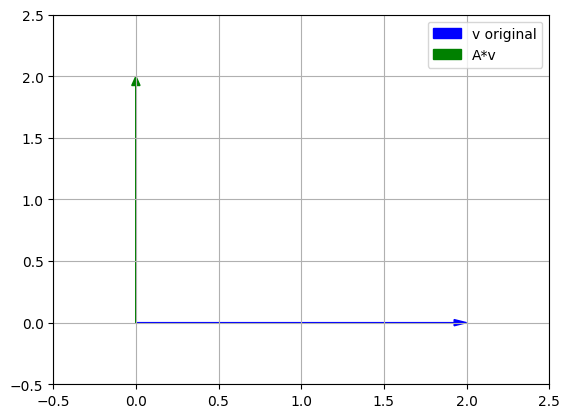

O resultado faz sentido geometricamente, no grafico podemos observar que o vetor rotacionou 90 graus.


In [650]:
A = torch.tensor( [[2., 0.], [0., 1.]])
v = torch.tensor([3., 5.])
b = torch.matmul(A, v)
print(f"b = Av: {b}")

theta_graus = torch.tensor(90.)
theta_rad = theta_graus * torch.pi / 180.   # 90° = π/2 rad

R = torch.tensor([[torch.cos(theta_rad), -torch.sin(theta_rad)], [torch.sin(theta_rad), torch.cos(theta_rad)]])
v = torch.tensor([2., 0.])
w = torch.matmul(R, v)
print(f"w: {w}")

# Para plotar as setas:

import matplotlib.pyplot as plt

ax = plt.gca()
ax.arrow(0, 0, v[0], v[1], head_width=0.05, color='blue', length_includes_head=True, label="v original")
ax.arrow(0, 0, w[0], w[1], head_width=0.05, color='green', length_includes_head=True, label="A*v")
plt.xlim(-.5, 2.5)
plt.ylim(-.5, 2.5)
plt.grid()
plt.legend()
plt.show()

print ("O resultado faz sentido geometricamente, no grafico podemos observar que o vetor rotacionou 90 graus.")

### Exercícios: Multiplicação de Matrizes

1.  **Compatibilidade**: Dadas as matrizes `A = torch.randn(4, 2)` e `B = torch.randn(2, 5)`, calcule o produto `C = A @ B`. Qual é o formato da matriz resultante? O produto `B @ A` é possível de ser calculado?
2.  **Não Comutatividade**: Crie duas matrizes quadradas `X` e `Y` de formato `(3, 3)` com números aleatórios. Mostre que `X @ Y` não é igual a `Y @ X`.
3.  **Matriz Identidade**: A matriz identidade `I` é o elemento neutro da multiplicação de matrizes ($AI = IA = A$). Crie uma matriz aleatória `A` de formato `(3, 3)` e uma matriz identidade `I` de mesmo formato (Dica: `torch.eye(3)`). Verifique que `A @ I` resulta na própria matriz `A`.

In [651]:
A = torch.randn(4, 2)
print()
print(f"A: {A}")

B = torch.randn(2, 5)
print()
print(f"B: {B}")


A: tensor([[ 0.6167, -0.3794],
        [-1.8454, -0.0548],
        [ 1.0412,  0.1738],
        [ 0.8152, -1.0660]])

B: tensor([[ 1.7847,  0.8483,  1.2144,  1.2070, -0.2046],
        [-0.2759,  1.1170, -0.0555,  2.0897, -0.3599]])


#### Exercício 1:

In [652]:

C = A @ B
print()
print(f"C=AxB: {C}")


C=AxB: tensor([[ 1.2053,  0.0993,  0.7700, -0.0485,  0.0104],
        [-3.2784, -1.6267, -2.2381, -2.3420,  0.3973],
        [ 1.8104,  1.0774,  1.2549,  1.6199, -0.2756],
        [ 1.7490, -0.4991,  1.0492, -1.2436,  0.2169]])


B@A nao pode ser calculado por que nao cumpre com o requisito de numero de colunas de B ser igual ao numero de linhas de A

#### Exercício 2:

In [653]:
X = torch.rand(3, 3)
Y = torch.rand(3, 3)

print()
print(f"X: {X}")
print()
print(f"Y: {Y}")


X: tensor([[0.9494, 0.4539, 0.2721],
        [0.9150, 0.0212, 0.9207],
        [0.7211, 0.5625, 0.1847]])

Y: tensor([[0.6969, 0.1407, 0.8380],
        [0.7796, 0.6700, 0.0681],
        [0.9718, 0.3912, 0.9424]])


In [654]:
primeiro = X@Y
print()
print(f"X@Y: {primeiro}")
segundo = Y@X
print()
print(f"Y@X: {segundo}")


X@Y: tensor([[1.2799, 0.5441, 1.0830],
        [1.5490, 0.5032, 1.6359],
        [1.1206, 0.5506, 0.8167]])

Y@X: tensor([[1.3947, 0.7907, 0.4740],
        [1.4024, 0.4064, 0.8416],
        [1.9601, 0.9794, 0.7987]])


Como podemos observar, X@Y e Y@X não são iguais.

#### Exercício 3:

In [655]:

A = torch.randn(3, 3)
I = torch.eye(3)

C = A @ I
print()
print(f"C=AxI: {C}")

print()
print("A matriz identidade é o elemento neutro da multiplicação de matrizes, ou seja, A@I = I@A = A")
print()
print(f"A@I: {A@I}")

print()
print(f"I@A: {I@A}")


C=AxI: tensor([[ 1.3621,  0.6482,  0.5050],
        [ 1.4635,  0.3763,  0.0265],
        [ 0.5128, -1.8342,  0.7395]])

A matriz identidade é o elemento neutro da multiplicação de matrizes, ou seja, A@I = I@A = A

A@I: tensor([[ 1.3621,  0.6482,  0.5050],
        [ 1.4635,  0.3763,  0.0265],
        [ 0.5128, -1.8342,  0.7395]])

I@A: tensor([[ 1.3621,  0.6482,  0.5050],
        [ 1.4635,  0.3763,  0.0265],
        [ 0.5128, -1.8342,  0.7395]])


### Exercícios: Distância entre Vetores

1.  **Distância Euclidiana**: Calcule a distância Euclidiana entre os pontos (vetores) `p1 = torch.tensor([2., 3.])` e `p2 = torch.tensor([5., 7.])`.
2.  **Ponto mais Próximo**: Dados três pontos, `A = torch.tensor([0., 0.])`, `B = torch.tensor([10., 0.])` e `C = torch.tensor([4., 5.])`, qual dos pontos (A ou B) está mais próximo do ponto C?
3.  **Impacto da Escala**: Calcule a distância entre `u = torch.tensor([1000., 1.])` e `v = torch.tensor([1001., 2.])`. Observe como a grande diferença na primeira dimensão domina completamente a distância total. Este é um dos motivos pelos quais a normalização de dados (vista nos exercícios de broadcasting) é tão importante em muitos algoritmos de IA.

####Exercicio 1: Distancia Euclidiana entre p1 e p2

In [656]:
p1 = torch.tensor([2., 3.])
p2 = torch.tensor([5., 7.])

print(f"p1: {p1}")
print(f"p2: {p2}")

p2_p1 = p2 - p1

print("Vetor p2 - p1:")
print(p2_p1)
dist_p2_p1 = torch.linalg.norm(p2_p1)

print("Distancia Euclidiana entre p1 e p2:")
print(dist_p2_p1)

p1_p2 = p1 - p2

print("Vetor p1 - p2:")
print(p1_p2)
dist_p1_p2 = torch.linalg.norm(p1_p2)

print("Distancia Euclidiana entre p2 e p1:")
print(dist_p1_p2)

if (dist_p2_p1 != dist_p1_p2):
    print("Algo errado em nossas contas, a distancia entre p2 e p1 nao é igual a distancia entre p1 e p2")
else:
    print("Como esperado, a distancia entre p1 e p2 e vice-versa é a mesma")

p1: tensor([2., 3.])
p2: tensor([5., 7.])
Vetor p2 - p1:
tensor([3., 4.])
Distancia Euclidiana entre p1 e p2:
tensor(5.)
Vetor p1 - p2:
tensor([-3., -4.])
Distancia Euclidiana entre p2 e p1:
tensor(5.)
Como esperado, a distancia entre p1 e p2 e vice-versa é a mesma


#### Exercicio 2: Ponto mais próximo

In [657]:

A = torch.tensor([0., 0.])
B = torch.tensor([10., 0.])
C = torch.tensor([4., 5.])

dist_A_C = torch.linalg.norm(C - A)
dist_B_C = torch.linalg.norm(C - B)

print("Distancia Euclidiana entre A e C:")
print(dist_A_C)

print("Distancia Euclidiana entre B e C:")
print(dist_B_C)

if (dist_A_C < dist_B_C):
    print("A esta mais perto de C que B")
else:
    print("B esta mais perto de C que A")


Distancia Euclidiana entre A e C:
tensor(6.4031)
Distancia Euclidiana entre B e C:
tensor(7.8102)
A esta mais perto de C que B


#### Exercicio 3: Impacto da escala

In [658]:
def exercicio3(u, v):
  print(f"u: {u}")
  print(f"v: {v}")

  w = v - u
  print(f"w = v - u: {w}")

  dist_u_v = torch.linalg.norm(w)
  print(f"Distancia Euclidiana entre u e v: {dist_u_v}")


In [659]:
print("Exemplo 1:")
u = torch.tensor([1000., 1.])
v = torch.tensor([1001., 2.])

exercicio3(u, v)

print()
print("Exemplo 2:")
u = torch.tensor([1000., 1.])
v = torch.tensor([1050., 2.])

exercicio3(u, v)


Exemplo 1:
u: tensor([1000.,    1.])
v: tensor([1001.,    2.])
w = v - u: tensor([1., 1.])
Distancia Euclidiana entre u e v: 1.4142135381698608

Exemplo 2:
u: tensor([1000.,    1.])
v: tensor([1050.,    2.])
w = v - u: tensor([50.,  1.])
Distancia Euclidiana entre u e v: 50.0099983215332


Com os numeros escolhidos originalmente, ambas dimensoes contribuem igualmente. 
Mas se utilizamos 1000 e 1050 por exemplo, vemos que a distancia possui contribuicao dominante da primeira dimensao.


### Exercícios: Broadcasting

1.  **Normalização Z-score (Standard Scaler)**: Um passo comum em pré-processamento de dados é subtrair a média e dividir pelo desvio padrão de cada característica (coluna).
    - Crie uma matriz de dados "falsos" de formato `(10, 3)`.
    - Calcule a média de cada coluna (o resultado será um vetor de formato `(3,)`).
    - Calcule o desvio padrão de cada coluna (resultado também será `(3,)`).
    - Usando broadcasting, subtraia o vetor de médias da matriz de dados.
    - Usando broadcasting novamente, divida o resultado pelo vetor de desvios padrão.
    O resultado é a sua matriz normalizada.
2.  **Compatibilidade (Teórico)**: Sem usar código, diga se as operações de broadcasting a seguir são válidas. Se sim, qual o formato do tensor resultante?
    - Tensor A `(5, 3)` + Tensor B `(1, 3)`
    - Tensor A `(5, 3)` + Tensor B `(5, 1)`
    - Tensor A `(5, 3)` + Tensor B `(3,)`
    - Tensor A `(4, 1, 3)` + Tensor B `(4, 5, 3)`

#### Exercicio 1:

In [660]:
sample_data = torch.randn(10, 3)
print("sample_data:")
print(sample_data)

media = torch.mean(sample_data, dim=0)
print("media:")
print(media)

desvio_padrao = torch.std(sample_data, dim=0)
print("desvio_padrao:")
print(desvio_padrao)

normalizado = (sample_data - media) / desvio_padrao
print("normalizado:")
print(normalizado)

sample_data:
tensor([[ 1.3978,  0.3146,  0.9711],
        [-0.4441, -0.5518, -0.9788],
        [ 0.3979, -2.0546,  0.6085],
        [-1.4417, -0.1781, -1.5096],
        [-0.5236, -0.2047,  0.0563],
        [ 0.3717, -0.9343,  0.6986],
        [-0.6338, -1.3812,  1.0942],
        [ 0.6652, -0.9595,  0.7924],
        [-0.4391, -1.1916,  0.9806],
        [-0.9905, -0.2181, -0.7322]])
media:
tensor([-0.1640, -0.7359,  0.1981])
desvio_padrao:
tensor([0.8531, 0.7033, 0.9411])
normalizado:
tensor([[ 1.8309,  1.4937,  0.8213],
        [-0.3284,  0.2619, -1.2505],
        [ 0.6587, -1.8751,  0.4360],
        [-1.4977,  0.7932, -1.8145],
        [-0.4215,  0.7554, -0.1507],
        [ 0.6280, -0.2821,  0.5318],
        [-0.5507, -0.9176,  0.9521],
        [ 0.9721, -0.3179,  0.6314],
        [-0.3224, -0.6479,  0.8314],
        [-0.9689,  0.7363, -0.9885]])


#### Exercício 2:

##### Caso 1:

In [661]:
A = torch.randn(5, 3)
B = torch.randn(1, 3)
C = A + B
print(f"A: {A}")
print(f"B: {B}")
print(f"Shape de C = A + B: {C.shape}")
print(f"C = A + B: {C}")


A: tensor([[ 0.4620,  1.4076,  0.2565],
        [ 0.3624, -0.2893, -0.1616],
        [ 0.1457,  0.4825, -2.9675],
        [ 0.8777, -0.7392,  1.5188],
        [ 0.4674, -1.5626,  0.8242]])
B: tensor([[-0.4898, -0.0009, -0.2652]])
Shape de C = A + B: torch.Size([5, 3])
C = A + B: tensor([[-0.0278,  1.4067, -0.0088],
        [-0.1273, -0.2902, -0.4269],
        [-0.3441,  0.4815, -3.2327],
        [ 0.3879, -0.7401,  1.2536],
        [-0.0223, -1.5635,  0.5589]])


##### Caso 2:

In [662]:

A = torch.randn(5, 3)
B = torch.randn(5, 1)
C = A + B
print(f"A: {A}")
print(f"B: {B}")
print(f"Shape de C = A + B: {C.shape}")
print(f"C = A + B: {C}")

A: tensor([[-0.6478, -1.0526, -1.2148],
        [ 0.9681, -0.3792, -0.6339],
        [ 1.1561,  1.7035,  0.5695],
        [-1.6294,  0.8450,  0.9527],
        [-0.4426,  0.4888, -0.5677]])
B: tensor([[ 0.4245],
        [ 1.0740],
        [-0.8279],
        [-0.2460],
        [ 0.0570]])
Shape de C = A + B: torch.Size([5, 3])
C = A + B: tensor([[-0.2233, -0.6281, -0.7903],
        [ 2.0421,  0.6949,  0.4401],
        [ 0.3282,  0.8756, -0.2585],
        [-1.8754,  0.5990,  0.7067],
        [-0.3856,  0.5459, -0.5107]])


##### Caso 3:

In [663]:

A = torch.randn(5, 3)
B = torch.randn(3)
C = A + B
print(f"A: {A}")
print(f"B: {B}")
print(f"Shape de C = A + B: {C.shape}")
print(f"C = A + B: {C}")


A: tensor([[ 1.4644, -0.0493,  0.6822],
        [ 1.8166, -0.5857, -0.0684],
        [-0.4670, -0.5785,  0.9036],
        [ 1.4436,  0.5856, -0.1077],
        [ 0.6707, -0.1874,  0.8316]])
B: tensor([0.5661, 0.0933, 1.3856])
Shape de C = A + B: torch.Size([5, 3])
C = A + B: tensor([[ 2.0304,  0.0440,  2.0678],
        [ 2.3826, -0.4924,  1.3173],
        [ 0.0990, -0.4853,  2.2893],
        [ 2.0097,  0.6789,  1.2780],
        [ 1.2368, -0.0942,  2.2173]])


##### Caso 4:

In [664]:

A = torch.randn(4, 1, 3)
B = torch.randn(4, 5, 3)
C = A + B
print(f"A: {A}")
print(f"B: {B}")
print(f"Shape de C = A + B: {C.shape}")
print(f"C = A + B: {C}")

A: tensor([[[-2.3159, -2.3425,  0.7034]],

        [[ 0.7101,  1.0143,  1.6397]],

        [[-1.5840,  0.0312,  2.3560]],

        [[ 0.5874, -0.4411, -0.5549]]])
B: tensor([[[-0.9521, -0.4585,  0.6181],
         [-1.1303,  1.2445,  0.8379],
         [ 0.4110, -1.1060,  0.5576],
         [-0.5906,  0.3852, -0.5668],
         [-1.2534,  0.4810, -0.9663]],

        [[ 0.6695,  1.6786, -1.4122],
         [ 0.7619,  0.2241,  0.8068],
         [-2.6525,  0.7010,  0.5191],
         [ 0.3071, -0.5513, -0.1941],
         [ 1.6028, -0.8194,  0.6792]],

        [[ 1.0149, -2.1599, -1.0804],
         [ 1.7483, -0.3111, -0.8533],
         [ 0.4769, -0.1286,  0.5141],
         [-0.4120, -0.7083, -2.3427],
         [ 0.8462,  0.0459, -0.4965]],

        [[-1.9062,  1.0453,  0.0138],
         [-0.8003, -0.2429,  1.8212],
         [-1.3657,  0.7617,  0.8384],
         [-1.3143,  0.9420,  1.0347],
         [-1.8404,  2.1729,  0.6369]]])
Shape de C = A + B: torch.Size([4, 5, 3])
C = A + B: tensor([[[-3.